In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import KFold # Import KFold for cross-validation

# Regressors
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.svm import SVR

# Optional: XGBoost if installed
try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    XGBRegressor = None
    xgb_available = False

# Paths (assumes notebook runs in c:\Coding\Challenge 2 or relative paths are correct)
train_path = 'D:/ai_pratice_prj/Team9_ML_edu/House Price/data/txt-preprocessing/train_processed.csv'
test_path = 'D:/ai_pratice_prj/Team9_ML_edu/House Price/data/txt-preprocessing/test_processed.csv'
y_path = 'D:/ai_pratice_prj/Team9_ML_edu/House Price/data/txt-preprocessing/y_train_log.csv'  # contains SalePrice_Log

# Output directory for predictions / evaluation
out_dir = 'model_predictions_with_cv_and_voting'
os.makedirs(out_dir, exist_ok=True)

print('Loading CSV files...')
if not os.path.exists(train_path):
    raise FileNotFoundError(f"{train_path} not found in notebook working directory: {os.getcwd()}")
if not os.path.exists(test_path):
    raise FileNotFoundError(f"{test_path} not found in notebook working directory: {os.getcwd()}")
if not os.path.exists(y_path):
    raise FileNotFoundError(f"{y_path} not found in notebook working directory: {os.getcwd()}")

X_full = pd.read_csv(train_path)
X_test = pd.read_csv(test_path)
y_df = pd.read_csv(y_path)

# Determine target column name in y_df
if 'SalePrice_Log' in y_df.columns:
    y_series = y_df['SalePrice_Log']
else:
    # if single-column CSV without header loaded as a column named something else or as the first column
    y_series = y_df.iloc[:,0]

print(f'Training features shape: {X_full.shape}')
print(f'Test features shape:     {X_test.shape}')
print(f'Target series length:    {len(y_series)}')

# Basic sanity check: lengths must match
if len(X_full) != len(y_series):
    raise ValueError('Number of rows in train_processed.csv does not match y_train_log.csv (target).')

# If train file accidentally includes target column, drop it (safe guard)
possible_targets = ['SalePrice', 'SalePrice_Log', 'Sale_Price', 'Target']
for t in possible_targets:
    if t in X_full.columns:
        print(f"Dropping target-like column '{t}' from X_full (was present in train_processed).")
        X_full = X_full.drop(columns=[t])

# Split for internal validation (e.g., 80% train, 20% val)
X_train, X_val, y_train, y_val = train_test_split(X_full, y_series, test_size=0.20, random_state=42)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')

# Define base models for both individual training and voting
base_models = {
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=5),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'LinearRegression': LinearRegression(),
    'SGDRegressor_Squared': SGDRegressor(loss='squared_error', random_state=42, max_iter=1000, tol=1e-3),
    'SVR': SVR(),
}

if xgb_available:
    base_models['XGBRegressor'] = XGBRegressor(random_state=42, n_estimators=100, verbosity=0)
else:
    print('XGBoost not available; skipping XGBRegressor.')

# --- Cross-Validation Setup ---
cv_folds = 5 # Number of folds for cross-validation
cv = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

# --- Individual Model Training, Cross-Validation, and Evaluation ---
results_individual = []

for name, model in base_models.items():
    print('\n---')
    print(f'Training and Cross-Validating {name}...')
    try:
        # Fit on the full training set
        model.fit(X_train, y_train)

        # Predict on validation set
        y_pred_val = model.predict(X_val)
        # Validation metrics (on log scale if y is logged)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        val_r2 = r2_score(y_val, y_pred_val)
        print(f'Internal Validation RMSE: {val_rmse:.6f}, R2: {val_r2:.6f}')

        # Perform Cross-Validation
        # Use neg_mean_squared_error and take the negative to get MSE, then sqrt for RMSE
        cv_neg_mse_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
        cv_mse_scores = -cv_neg_mse_scores
        cv_rmse_scores = np.sqrt(cv_mse_scores)
        cv_rmse_mean = cv_rmse_scores.mean()
        cv_rmse_std = cv_rmse_scores.std()
        print(f'Cross-Validation RMSE (mean ± std): {cv_rmse_mean:.6f} ± {cv_rmse_std:.6f}')

        # Predict on provided test_processed.csv
        y_pred_test = model.predict(X_test)

        # Save predictions CSV. If you need original SalePrice instead of log, exponentiate here:
        # submission_price = np.exp(y_pred_test)  # uncomment if y was log-transformed and sample expects original prices
        submission_price = y_pred_test

        # Create Id column if not available: use 1-based index
        ids = None
        # try to find 'Id' column in X_test if present
        if 'Id' in X_test.columns:
            ids = X_test['Id']
        else:
            ids = pd.RangeIndex(start=1, stop=len(X_test)+1)

        submission_df = pd.DataFrame({'Id': ids, 'Prediction': submission_price})
        out_file = os.path.join(out_dir, f'submission_{name}_individual.csv')
        submission_df.to_csv(out_file, index=False)
        print(f'Saved individual test predictions to: {out_file}')

        results_individual.append({
            'Model': name,
            'Validation_RMSE': float(val_rmse),
            'Validation_R2': float(val_r2),
            'CV_RMSE_Mean': float(cv_rmse_mean),
            'CV_RMSE_Std': float(cv_rmse_std)
        })
    except Exception as e:
        print(f'Error training/evaluating {name}: {e}')
        results_individual.append({
            'Model': name,
            'Validation_RMSE': np.nan,
            'Validation_R2': np.nan,
            'CV_RMSE_Mean': np.nan,
            'CV_RMSE_Std': np.nan
        })

# --- Voting Regressor Training and Evaluation ---
print('\n---')
print('Training Voting Regressor...')
# Select a subset of models for the voting ensemble
# Example: Top performing individual models from previous runs could be chosen
# For now, let's use a few diverse ones: RandomForest, GradientBoosting, LinearRegression
voting_estimators = []
voting_names = ['RandomForestRegressor', 'GradientBoostingRegressor', 'LinearRegression']
for name in voting_names:
    if name in base_models:
        voting_estimators.append((name, base_models[name]))

if voting_estimators:
    voting_regressor = VotingRegressor(estimators=voting_estimators)
    try:
        # Fit the voting regressor on the full training set
        voting_regressor.fit(X_train, y_train)

        # Predict on validation set
        y_pred_val_voting = voting_regressor.predict(X_val)
        # Validation metrics for voting regressor
        val_rmse_voting = np.sqrt(mean_squared_error(y_val, y_pred_val_voting))
        val_r2_voting = r2_score(y_val, y_pred_val_voting)
        print(f'Voting Regressor Validation RMSE: {val_rmse_voting:.6f}, R2: {val_r2_voting:.6f}')

        # Perform Cross-Validation for the Voting Regressor
        cv_neg_mse_scores_voting = cross_val_score(voting_regressor, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
        cv_mse_scores_voting = -cv_neg_mse_scores_voting
        cv_rmse_scores_voting = np.sqrt(cv_mse_scores_voting)
        cv_rmse_mean_voting = cv_rmse_scores_voting.mean()
        cv_rmse_std_voting = cv_rmse_scores_voting.std()
        print(f'Voting Regressor Cross-Validation RMSE (mean ± std): {cv_rmse_mean_voting:.6f} ± {cv_rmse_std_voting:.6f}')

        # Predict on provided test_processed.csv using the voting regressor
        y_pred_test_voting = voting_regressor.predict(X_test)

        # Save predictions CSV for voting regressor
        submission_price_voting = y_pred_test_voting

        # Create Id column if not available: use 1-based index
        ids_voting = None
        # try to find 'Id' column in X_test if present
        if 'Id' in X_test.columns:
            ids_voting = X_test['Id']
        else:
            ids_voting = pd.RangeIndex(start=1, stop=len(X_test)+1)

        submission_df_voting = pd.DataFrame({'Id': ids_voting, 'Prediction': submission_price_voting})
        out_file_voting = os.path.join(out_dir, f'submission_voting_regressor.csv')
        submission_df_voting.to_csv(out_file_voting, index=False)
        print(f'Saved voting regressor test predictions to: {out_file_voting}')

        # Add voting regressor results to the individual results list for a combined summary
        results_individual.append({
            'Model': 'VotingRegressor',
            'Validation_RMSE': float(val_rmse_voting),
            'Validation_R2': float(val_r2_voting),
            'CV_RMSE_Mean': float(cv_rmse_mean_voting),
            'CV_RMSE_Std': float(cv_rmse_std_voting)
        })
    except Exception as e:
        print(f'Error training/evaluating Voting Regressor: {e}')
        results_individual.append({
            'Model': 'VotingRegressor',
            'Validation_RMSE': np.nan,
            'Validation_R2': np.nan,
            'CV_RMSE_Mean': np.nan,
            'CV_RMSE_Std': np.nan
        })
else:
    print("No valid estimators found for Voting Regressor.")

# --- Save Evaluation Summary ---
results_df = pd.DataFrame(results_individual)
results_csv = os.path.join(out_dir, 'model_evaluation_summary_cv_voting.csv')
results_df.to_csv(results_csv, index=False)
print('\nEvaluation summary (including voting regressor) saved to:', results_csv)

print('\nSummary (Individual Models & Voting Regressor):')
print(results_df.to_string(index=False, float_format='%.6f'))

print('\nAll done. Check the', out_dir, 'directory for per-model prediction files and evaluation summary.')


Loading CSV files...
Training features shape: (1460, 236)
Test features shape:     (1459, 236)
Target series length:    1460
X_train: (1168, 236), X_val: (292, 236)

---
Training and Cross-Validating KNeighborsRegressor...
Internal Validation RMSE: 0.180123, R2: 0.826139
Cross-Validation RMSE (mean ± std): 0.172188 ± 0.014229
Saved individual test predictions to: model_predictions_with_cv_and_voting\submission_KNeighborsRegressor_individual.csv

---
Training and Cross-Validating RandomForestRegressor...
Internal Validation RMSE: 0.148157, R2: 0.882372
Cross-Validation RMSE (mean ± std): 0.146509 ± 0.014996
Saved individual test predictions to: model_predictions_with_cv_and_voting\submission_RandomForestRegressor_individual.csv

---
Training and Cross-Validating GradientBoostingRegressor...
Internal Validation RMSE: 0.137578, R2: 0.898571
Cross-Validation RMSE (mean ± std): 0.131366 ± 0.020066
Saved individual test predictions to: model_predictions_with_cv_and_voting\submission_Gradient

In [ ]:
# Convert submission files so output contains Id and SalePrice, set Id range, and remove Prediction column
import os
import numpy as np
import pandas as pd

out_dir = 'model_predictions_with_cv_and_voting'
if not os.path.exists(out_dir):
    raise FileNotFoundError(f"Output directory not found: {out_dir}")

# Set start_id to the desired first Id (e.g. 1461).
# Set to None to preserve existing Ids in the file.
start_id = 1461

for fname in sorted(os.listdir(out_dir)):
    if not (fname.startswith('submission_') and fname.endswith('.csv')):
        continue
    path = os.path.join(out_dir, fname)
    df = pd.read_csv(path)

    # If neither Prediction nor SalePrice present, skip
    if ('Prediction' not in df.columns) and ('SalePrice' not in df.columns):
        print(f"Skipping {fname}: neither 'Prediction' nor 'SalePrice' column found")
        continue

    # If SalePrice already exists, keep it. Otherwise compute from Prediction.
    conversion = 'existing'
    if 'SalePrice' in df.columns:
        saleprice = df['SalePrice']
    else:
        pred = df['Prediction']
        # Heuristic: detect if predictions are log-transformed
        force_log = None  # set True/False to override
        if force_log is True:
            saleprice = np.exp(pred)
            conversion = 'exp (forced)'
        elif force_log is False:
            saleprice = pred
            conversion = 'identity (forced)'
        else:
            if (pred.max() < 60) or (pred.mean() < 30):
                saleprice = np.exp(pred)
                conversion = 'exp (auto)'
            else:
                saleprice = pred
                conversion = 'identity (auto)'

    df['SalePrice'] = saleprice

    # Remove Prediction column if present
    prediction_dropped = False
    if 'Prediction' in df.columns:
        df = df.drop(columns=['Prediction'])
        prediction_dropped = True

    # Overwrite or create Id column if start_id provided
    if start_id is not None:
        df['Id'] = pd.RangeIndex(start=start_id, stop=start_id + len(df))

    # Write output
    out_name = fname.replace('.csv', '_with_SalePrice.csv')
    out_path = os.path.join(out_dir, out_name)
    df.to_csv(out_path, index=False)
    print(f'Wrote {out_name} from {fname} — conversion: {conversion}; prediction_dropped: {prediction_dropped}; ids_start: {start_id if start_id is not None else "original"}')


Wrote submission_DecisionTreeRegressor_individual_with_SalePrice.csv from submission_DecisionTreeRegressor_individual.csv — conversion: exp (auto); prediction_dropped: True; ids_start: 1461
Wrote submission_GradientBoostingRegressor_individual_with_SalePrice.csv from submission_GradientBoostingRegressor_individual.csv — conversion: exp (auto); prediction_dropped: True; ids_start: 1461
Wrote submission_KNeighborsRegressor_individual_with_SalePrice.csv from submission_KNeighborsRegressor_individual.csv — conversion: exp (auto); prediction_dropped: True; ids_start: 1461
Wrote submission_LinearRegression_individual_with_SalePrice.csv from submission_LinearRegression_individual.csv — conversion: identity (auto); prediction_dropped: True; ids_start: 1461
Wrote submission_RandomForestRegressor_individual_with_SalePrice.csv from submission_RandomForestRegressor_individual.csv — conversion: exp (auto); prediction_dropped: True; ids_start: 1461
Wrote submission_SGDRegressor_Squared_individual_wi

                       Model  Validation_RMSE  Validation_R2  CV_RMSE_Mean  \
0        KNeighborsRegressor     1.801230e-01   8.261395e-01  1.721875e-01   
1      RandomForestRegressor     1.481575e-01   8.823722e-01  1.465087e-01   
2  GradientBoostingRegressor     1.375783e-01   8.985709e-01  1.313659e-01   
3      DecisionTreeRegressor     1.997081e-01   7.862755e-01  2.129739e-01   
4           LinearRegression     7.338135e+09  -2.885587e+20  5.964074e+10   
5       SGDRegressor_Squared     2.167751e-01   7.481850e-01  2.616116e-01   
6                        SVR     1.383687e-01   8.974020e-01  1.279333e-01   
7               XGBRegressor     1.562388e-01   8.691901e-01  1.428153e-01   
8            VotingRegressor     2.446045e+09  -3.206208e+19  1.988025e+10   

    CV_RMSE_Std  
0  1.422928e-02  
1  1.499588e-02  
2  2.006637e-02  
3  1.769694e-02  
4  1.145775e+11  
5  2.751821e-02  
6  1.907742e-02  
7  2.122794e-02  
8  3.819251e+10  


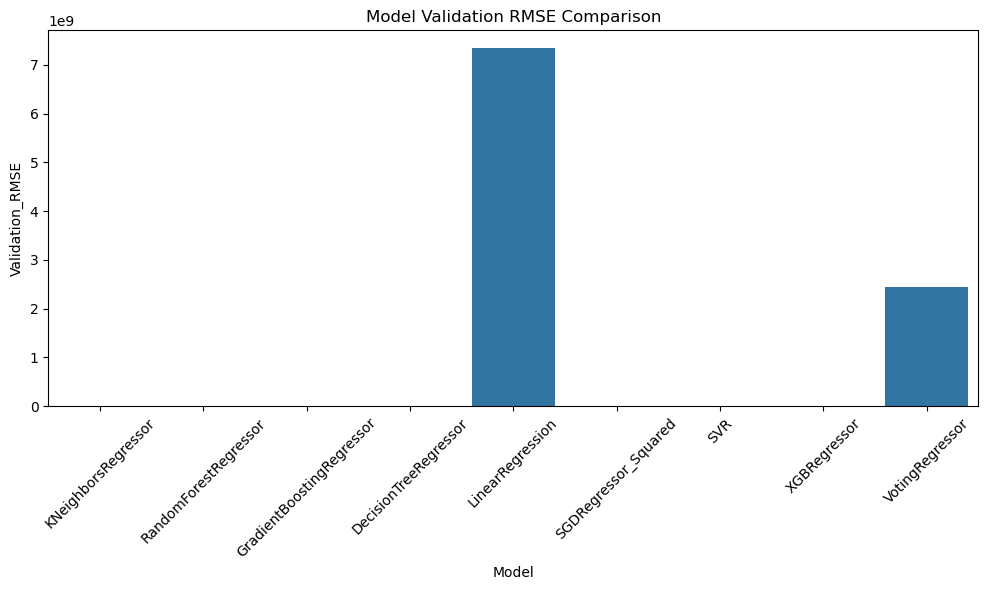

In [ ]:
# Example output of model_evaluation_summary.csv:
#Model,Validation_RMSE,Validation_R2
# KNeighborsRegressor,,
# RandomForestRegressor,0.14396089800479991,0.8889414802898344
# GradientBoostingRegressor,,
# DecisionTreeRegressor,0.20454904179175104,0.7757886027276378
# LinearRegression,,
# SGDRegressor_Squared,,
# SVR,,
# XGBRegressor,0.14491320837597244,0.8874673023244872

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load evaluation summary
eval_path = 'model_predictions_with_cv_and_voting/model_evaluation_summary_cv_voting.csv'
eval_df = pd.read_csv(eval_path)
print(eval_df)
# Plot Validation RMSE
plt.figure(figsize=(10,6))
sns.barplot(data=eval_df, x='Model', y='Validation_RMSE')
plt.title('Model Validation RMSE Comparison')
plt.xticks(rotation=45)
plt.tight_layout()


In [ ]:
#After submission on kaggle:
#Random forest: 0.54920
#Decision tree: 0.56015
#XGBoost: 0.56058


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import json
import time

# Hyperparameter tuning (RandomizedSearchCV) for all models in the notebook environment.
# Uses existing objects: models (or base_models), X_train, y_train, X_val, y_val, cv.
# Saves a CSV summary and pickled best-estimators to a results directory.


results_dir = "hyperparam_results"
os.makedirs(results_dir, exist_ok=True)

# Use whichever dict exists in the notebook
model_dict = globals().get('models') or globals().get('base_models')
if model_dict is None:
    raise RuntimeError("No models or base_models dict found in the notebook.")

# Parameter distributions / grids for randomized search
param_distributions = {
    'KNeighborsRegressor': {
        'n_neighbors': [3,5,7,9,11],
        'weights': ['uniform','distance'],
        'p': [1,2]
    },
    'RandomForestRegressor': {
        'n_estimators': [100,200,400],
        'max_depth': [None,10,20,30],
        'max_features': ['sqrt','log2',0.5],
        'min_samples_split': [2,5,10]
    },
    'GradientBoostingRegressor': {
        'n_estimators': [100,200,400],
        'learning_rate': [0.01,0.05,0.1],
        'max_depth': [3,5,7],
        'subsample': [0.6,0.8,1.0]
    },
    'DecisionTreeRegressor': {
        'max_depth': [None,5,10,20,30],
        'min_samples_split': [2,5,10],
        'min_samples_leaf': [1,2,4]
    },
    'LinearRegression': {
        'fit_intercept': [True, False],
        # not many hyperparams for plain LinearRegression
    },
    'SGDRegressor_Squared': {
        'penalty': ['l2','l1','elasticnet'],
        'alpha': [1e-4, 1e-3, 1e-2, 1e-1],
        'learning_rate': ['invscaling','constant','optimal'],
        'max_iter': [500,1000,2000]
    },
    'SVR': {
        'C': [0.1, 1.0, 10.0, 50.0],
        'kernel': ['rbf','linear','poly'],
        'gamma': ['scale','auto']
    },
    # XGBoost (only include if available)
    'XGBRegressor': {
        'n_estimators': [100,200,400],
        'learning_rate': [0.01,0.05,0.1],
        'max_depth': [3,5,7],
        'subsample': [0.6,0.8,1.0],
        'colsample_bytree': [0.6,0.8,1.0]
    }
}

# How many iterations for RandomizedSearchCV per model (can be tuned per-model)
default_n_iter = 20
n_iter_map = {
    'LinearRegression': 4,  # tiny grid
    'KNeighborsRegressor': 12,
    'SVR': 16,
    'SGDRegressor_Squared': 24,
    'DecisionTreeRegressor': 16,
    'GradientBoostingRegressor': 24,
    'RandomForestRegressor': 24,
    'XGBRegressor': 30
}

summary = []
start_all = time.time()

for name, estimator in model_dict.items():
    print(f"\n=== Tuning {name} ===")
    # Skip XGB if not available in environment
    if name == 'XGBRegressor' and not globals().get('xgb_available', False):
        print("XGBoost not available, skipping.")
        continue

    params = param_distributions.get(name)
    if not params:
        # if no grid defined, just evaluate the default estimator
        print(f"No param distribution defined for {name}, skipping search and evaluating default.")
        try:
            estimator.fit(X_train, y_train)
            y_val_pred = estimator.predict(X_val)
            val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
            val_r2 = r2_score(y_val, y_val_pred)
            best_params = {}
            best_score_rmse = val_rmse
            best_estimator = estimator
        except Exception as e:
            print(f"Error fitting default {name}: {e}")
            best_params = {}
            best_score_rmse = np.nan
            val_r2 = np.nan
            best_estimator = estimator
        summary.append({
            'Model': name,
            'Best_RMSE_on_cv': best_score_rmse,
            'Validation_RMSE': val_rmse if 'val_rmse' in locals() else np.nan,
            'Validation_R2': val_r2 if 'val_r2' in locals() else np.nan,
            'Best_Params': json.dumps(best_params)
        })
        # save default estimator
        joblib.dump(best_estimator, os.path.join(results_dir, f'best_{name}.pkl'))
        continue

    n_iter = n_iter_map.get(name, default_n_iter)
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=params,
        n_iter=n_iter,
        scoring='neg_mean_squared_error',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=False
    )

    t0 = time.time()
    try:
        search.fit(X_train, y_train)
        elapsed = time.time() - t0
        # best cv score is negative MSE
        best_neg_mse = search.best_score_
        best_rmse_cv = np.sqrt(-best_neg_mse) if not np.isnan(best_neg_mse) else np.nan

        best_params = search.best_params_
        best_estimator = search.best_estimator_

        # evaluate on validation set
        y_val_pred = best_estimator.predict(X_val)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        val_r2 = r2_score(y_val, y_val_pred)

        print(f"{name} best CV RMSE: {best_rmse_cv:.6f} (search time {elapsed:.1f}s)")
        print(f"{name} validation RMSE: {val_rmse:.6f}, R2: {val_r2:.6f}")

        # store summary
        summary.append({
            'Model': name,
            'Best_RMSE_on_cv': float(best_rmse_cv) if not np.isnan(best_rmse_cv) else np.nan,
            'Validation_RMSE': float(val_rmse),
            'Validation_R2': float(val_r2),
            'Best_Params': json.dumps(best_params)
        })

        # persist best estimator and the cv results briefly
        joblib.dump(best_estimator, os.path.join(results_dir, f'best_{name}.pkl'))
        # save search.cv_results_ (lightweight subset)
        try:
            cvres = search.cv_results_
            small = {
                'params': cvres.get('params', [])[:50],
                'mean_test_score': (cvres.get('mean_test_score', [])[:50]).tolist() if 'mean_test_score' in cvres else [],
                'std_test_score': (cvres.get('std_test_score', [])[:50]).tolist() if 'std_test_score' in cvres else []
            }
            with open(os.path.join(results_dir, f'cv_results_{name}.json'), 'w') as fh:
                json.dump(small, fh)
        except Exception:
            pass

    except Exception as e:
        print(f"Search failed for {name}: {e}")
        summary.append({
            'Model': name,
            'Best_RMSE_on_cv': np.nan,
            'Validation_RMSE': np.nan,
            'Validation_R2': np.nan,
            'Best_Params': json.dumps({'error': str(e)})
        })

total_elapsed = time.time() - start_all
print(f"\nHyperparameter tuning finished in {total_elapsed:.1f}s. Saving summary to CSV.")

summary_df = pd.DataFrame(summary).sort_values('Validation_RMSE', na_position='last')
summary_csv = os.path.join(results_dir, 'hyperparam_tuning_summary.csv')
summary_df.to_csv(summary_csv, index=False)
print("Wrote:", summary_csv)
print(summary_df.to_string(index=False))



=== Tuning KNeighborsRegressor ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
KNeighborsRegressor best CV RMSE: 0.160764 (search time 4.1s)
KNeighborsRegressor validation RMSE: 0.181567, R2: 0.823341

=== Tuning RandomForestRegressor ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits
RandomForestRegressor best CV RMSE: 0.141543 (search time 25.3s)
RandomForestRegressor validation RMSE: 0.147654, R2: 0.883170

=== Tuning GradientBoostingRegressor ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits
GradientBoostingRegressor best CV RMSE: 0.123753 (search time 36.0s)
GradientBoostingRegressor validation RMSE: 0.137741, R2: 0.898330

=== Tuning DecisionTreeRegressor ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
DecisionTreeRegressor best CV RMSE: 0.195746 (search time 0.3s)
DecisionTreeRegressor validation RMSE: 0.192977, R2: 0.800439

=== Tuning LinearRegression ===
Fitting 5 folds for each of 2 candidates, totalling 10 fi

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 2 is smaller than n_iter=4. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


SGDRegressor_Squared best CV RMSE: 0.263055 (search time 2.4s)
SGDRegressor_Squared validation RMSE: 0.216775, R2: 0.748185

=== Tuning SVR ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
SVR best CV RMSE: 0.126862 (search time 138.0s)
SVR validation RMSE: 0.136469, R2: 0.900201

=== Tuning XGBRegressor ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits
XGBRegressor best CV RMSE: 0.125166 (search time 25.4s)
XGBRegressor validation RMSE: 0.137008, R2: 0.899411

Hyperparameter tuning finished in 231.9s. Saving summary to CSV.
Wrote: hyperparam_results\hyperparam_tuning_summary.csv
                    Model  Best_RMSE_on_cv  Validation_RMSE  Validation_R2                                                                                             Best_Params
                      SVR         0.126862         0.136469       0.900201                                                            {"kernel": "rbf", "gamma": "auto", "C": 1.0}
             XGBRegress

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.svm import SVR
import numpy as np

# Optional: XGBoost if installed
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    XGBRegressor = None
    xgb_available = False

# --- Configuration ---
# Define the parameter grids for each model
param_grids = {
    'KNeighborsRegressor': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]  # 1 for Manhattan, 2 for Euclidean
    },
    'RandomForestRegressor': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'GradientBoostingRegressor': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'DecisionTreeRegressor': {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'LinearRegression': {
        # Linear Regression typically has no hyperparameters to tune in a standard grid search context
        # You could tune fit_intercept or normalize (deprecated), but it's often skipped.
        # For demonstration, let's pass an empty grid or a trivial one.
        # An empty grid means the default parameters are used.
        # Or you could include regularization like Ridge/Lasso, but that's a different model.
        # We'll include it here with an empty grid to show default performance.
    },
    'SGDRegressor_Squared': {
        'loss': ['squared_error', 'huber'],
        'penalty': ['l2', 'l1', 'elasticnet'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'optimal', 'adaptive'],
        'max_iter': [1000, 2000]
    },
    'SVR': {
        'C': [0.1, 1, 10, 100],
        'epsilon': [0.01, 0.1, 0.2],
        'kernel': ['rbf', 'linear'] # Adding linear for comparison, though rbf is often preferred
        # Note: gamma is relevant for 'rbf', 'poly' and 'sigmoid' kernels
        # For 'linear', it's ignored. We could add gamma if kernel is rbf/poly/sigmoid,
        # but for simplicity in this grid, we'll stick to rbf and linear.
        # If using rbf, consider adding gamma: ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    },
}

if xgb_available:
    param_grids['XGBRegressor'] = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }

# Paths
train_path = 'train_processed.csv'
y_path = 'y_train_log.csv'

print('Loading CSV files...')
if not os.path.exists(train_path):
    raise FileNotFoundError(f"{train_path} not found.")
if not os.path.exists(y_path):
    raise FileNotFoundError(f"{y_path} not found.")

X_full = pd.read_csv(train_path)
y_df = pd.read_csv(y_path)

# Determine target column name in y_df
if 'SalePrice_Log' in y_df.columns:
    y_series = y_df['SalePrice_Log']
else:
    y_series = y_df.iloc[:, 0] # Fallback

print(f'Training features shape: {X_full.shape}')
print(f'Target series length:    {len(y_series)}')

# Basic sanity check: lengths must match
if len(X_full) != len(y_series):
    raise ValueError('Number of rows in train_processed.csv does not match y_train_log.csv (target).')

# If train file accidentally includes target column, drop it
possible_targets = ['SalePrice', 'SalePrice_Log', 'Sale_Price', 'Target']
for t in possible_targets:
    if t in X_full.columns:
        print(f"Dropping target-like column '{t}' from X_full.")
        X_full = X_full.drop(columns=[t])

# Split for hyperparameter tuning (use train_test_split implicitly via GridSearchCV's internal CV)
X_train, X_val, y_train, y_val = train_test_split(X_full, y_series, test_size=0.20, random_state=42)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')

# --- Hyperparameter Tuning Loop ---
results = {}

for name, base_model in param_grids.items():
    print(f"\n--- Tuning {name} ---")
    # Retrieve the actual model instance from the original script's logic or define here
    # Since the original script defined base_models, we reconstruct them here for tuning.
    # This avoids redefining the base models dictionary again.
    if name == 'KNeighborsRegressor':
        model_instance = KNeighborsRegressor()
        param_grid = param_grids[name]
    elif name == 'RandomForestRegressor':
        model_instance = RandomForestRegressor(random_state=42)
        param_grid = param_grids[name]
    elif name == 'GradientBoostingRegressor':
        model_instance = GradientBoostingRegressor(random_state=42)
        param_grid = param_grids[name]
    elif name == 'DecisionTreeRegressor':
        model_instance = DecisionTreeRegressor(random_state=42)
        param_grid = param_grids[name]
    elif name == 'LinearRegression':
        model_instance = LinearRegression()
        param_grid = param_grids[name] # Empty dict
    elif name == 'SGDRegressor_Squared':
        model_instance = SGDRegressor(random_state=42, tol=1e-3)
        param_grid = param_grids[name]
    elif name == 'SVR':
        model_instance = SVR()
        param_grid = param_grids[name]
    elif name == 'XGBRegressor' and xgb_available:
        model_instance = XGBRegressor(random_state=42, verbosity=0)
        param_grid = param_grids[name]
    else:
        if name == 'XGBRegressor' and not xgb_available:
             print(f"XGBoost not available; skipping tuning for {name}.")
        continue # Skip if model not available or not in main list

    # Perform Grid Search with Cross-Validation
    # Using neg_mean_squared_error as the scoring metric (higher is better, so more negative MSE is worse)
    grid_search = GridSearchCV(
        estimator=model_instance,
        param_grid=param_grid,
        cv=5, # 5-fold cross-validation
        scoring='neg_mean_squared_error', # Use negative MSE
        n_jobs=-1, # Use all available cores
        verbose=1 # Print progress
    )

    try:
        grid_search.fit(X_train, y_train)
        best_estimator = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_score = grid_search.best_score_ # This is the *mean* neg MSE from CV

        # Calculate RMSE from the best CV score (neg MSE)
        best_cv_rmse = np.sqrt(-best_score) # Negate the neg MSE to get MSE, then sqrt

        results[name] = {
            'best_params': best_params,
            'best_cv_rmse': best_cv_rmse,
            'best_estimator': best_estimator # Store the fitted best estimator if needed later
        }

        print(f"Best parameters for {name}: {best_params}")
        print(f"Best CV RMSE (on log scale): {best_cv_rmse:.6f}")
    except Exception as e:
        print(f"Error tuning {name}: {e}")
        results[name] = {
            'best_params': 'Error',
            'best_cv_rmse': np.nan,
            'best_estimator': None
        }

# --- Output Results in Plaintext ---
print("\n" + "="*50)
print("HYPERPARAMETER TUNING RESULTS")
print("="*50)
for model_name, result in results.items():
    print(f"\nModel: {model_name}")
    if result['best_params'] != 'Error':
        print(f"  Best Parameters: {result['best_params']}")
        print(f"  Best CV RMSE (log scale): {result['best_cv_rmse']:.6f}")
    else:
        print(f"  Status: {result['best_params']}")

print("\nTuning complete.")


Loading CSV files...


FileNotFoundError: train_processed.csv not found.

In [ ]:
#After tuning: 


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import KFold # Import KFold for cross-validation

# Regressors
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.svm import SVR

# XGBoost (required for the tuned model)
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    print("XGBoost not found. Please install it using 'pip install xgboost'.")
    xgb_available = False
    # If XGBoost is not available, the script will raise an error later as XGB is specifically needed here.

if not xgb_available:
    raise ImportError("XGBoost is required to run this script with the tuned parameters.")

# Paths (assumes notebook runs in c:\Coding\Challenge 2 or relative paths are correct)
train_path = 'train_processed.csv'
test_path = 'test_processed.csv'
y_path = 'y_train_log.csv'  # contains SalePrice_Log

# Output directory for predictions / evaluation
out_dir = 'xgb_tuned_predictions'
os.makedirs(out_dir, exist_ok=True)

print('Loading CSV files...')
if not os.path.exists(train_path):
    raise FileNotFoundError(f"{train_path} not found in notebook working directory: {os.getcwd()}")
if not os.path.exists(test_path):
    raise FileNotFoundError(f"{test_path} not found in notebook working directory: {os.getcwd()}")
if not os.path.exists(y_path):
    raise FileNotFoundError(f"{y_path} not found in notebook working directory: {os.getcwd()}")

X_full = pd.read_csv(train_path)
X_test = pd.read_csv(test_path)
y_df = pd.read_csv(y_path)

# Determine target column name in y_df
if 'SalePrice_Log' in y_df.columns:
    y_series = y_df['SalePrice_Log']
else:
    # if single-column CSV without header loaded as a column named something else or as the first column
    y_series = y_df.iloc[:,0]

print(f'Training features shape: {X_full.shape}')
print(f'Test features shape:     {X_test.shape}')
print(f'Target series length:    {len(y_series)}')

# Basic sanity check: lengths must match
if len(X_full) != len(y_series):
    raise ValueError('Number of rows in train_processed.csv does not match y_train_log.csv (target).')

# If train file accidentally includes target column, drop it (safe guard)
possible_targets = ['SalePrice', 'SalePrice_Log', 'Sale_Price', 'Target']
for t in possible_targets:
    if t in X_full.columns:
        print(f"Dropping target-like column '{t}' from X_full (was present in train_processed).")
        X_full = X_full.drop(columns=[t])

# Split for internal validation (e.g., 80% train, 20% val)
X_train, X_val, y_train, y_val = train_test_split(X_full, y_series, test_size=0.20, random_state=42)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')

# --- Define Models, including the Tuned XGBoost ---
# Use the best parameters found from tuning
tuned_xgb_model = XGBRegressor(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=200,
    subsample=0.8,
    random_state=42, # Set for reproducibility
    verbosity=0 # Suppress output during fitting/prediction
)

# Define the models dictionary, including the tuned XGB
# You can include other models if desired, or just focus on the tuned XGB
models = {
    'XGBRegressor_Tuned': tuned_xgb_model,
    # Example: Include other models if needed
    # 'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=42),
    # 'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
}

# --- Cross-Validation Setup ---
cv_folds = 5 # Number of folds for cross-validation
cv = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

# --- Model Training, Cross-Validation, and Evaluation for Tuned XGB ---
results = []

for name, model in models.items():
    print('\n---')
    print(f'Training and Cross-Validating {name}...')
    try:
        # Fit on the full training set
        model.fit(X_train, y_train)

        # Predict on validation set
        y_pred_val = model.predict(X_val)
        # Validation metrics (on log scale if y is logged)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        val_r2 = r2_score(y_val, y_pred_val)
        print(f'Internal Validation RMSE: {val_rmse:.6f}, R2: {val_r2:.6f}')

        # Perform Cross-Validation (optional, but good for double-checking)
        # Use neg_mean_squared_error and take the negative to get MSE, then sqrt for RMSE
        cv_neg_mse_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
        cv_mse_scores = -cv_neg_mse_scores
        cv_rmse_scores = np.sqrt(cv_mse_scores)
        cv_rmse_mean = cv_rmse_scores.mean()
        cv_rmse_std = cv_rmse_scores.std()
        print(f'Cross-Validation RMSE (mean ± std): {cv_rmse_mean:.6f} ± {cv_rmse_std:.6f}')

        # Predict on provided test_processed.csv
        y_pred_test = model.predict(X_test)

        # Save predictions CSV. Since the model was trained on log scale, predictions are on log scale.
        # If the competition requires the original scale, you would exponentiate: np.exp(y_pred_test)
        submission_price = y_pred_test # Keep as log scale prediction

        # Create Id column if not available: use 1-based index or load from sample_submission if available
        ids = None
        # try to find 'Id' column in X_test if present
        if 'Id' in X_test.columns:
            ids = X_test['Id']
        else:
            ids = pd.RangeIndex(start=1, stop=len(X_test)+1)

        submission_df = pd.DataFrame({'Id': ids, 'SalePrice': submission_price})
        out_file = os.path.join(out_dir, f'submission_{name}.csv')
        submission_df.to_csv(out_file, index=False)
        print(f'Saved test predictions to: {out_file}')

        results.append({
            'Model': name,
            'Validation_RMSE': float(val_rmse),
            'Validation_R2': float(val_r2),
            'CV_RMSE_Mean': float(cv_rmse_mean),
            'CV_RMSE_Std': float(cv_rmse_std)
        })
    except Exception as e:
        print(f'Error training/evaluating {name}: {e}')
        results.append({
            'Model': name,
            'Validation_RMSE': np.nan,
            'Validation_R2': np.nan,
            'CV_RMSE_Mean': np.nan,
            'CV_RMSE_Std': np.nan
        })

# --- Save Evaluation Summary ---
results_df = pd.DataFrame(results)
results_csv = os.path.join(out_dir, 'tuned_xgb_evaluation_summary.csv')
results_df.to_csv(results_csv, index=False)
print('\nEvaluation summary for tuned XGB saved to:', results_csv)

print('\nSummary (Tuned XGB):')
print(results_df.to_string(index=False, float_format='%.6f'))

print('\nAll done. Check the', out_dir, 'directory for prediction files and evaluation summary.')


Loading CSV files...
Training features shape: (1460, 249)
Test features shape:     (1460, 249)
Target series length:    1460
X_train: (1168, 249), X_val: (292, 249)

---
Training and Cross-Validating XGBRegressor_Tuned...
Internal Validation RMSE: 0.133797, R2: 0.904070
Cross-Validation RMSE (mean ± std): 0.123690 ± 0.016160
Saved test predictions to: xgb_tuned_predictions\submission_XGBRegressor_Tuned.csv

Evaluation summary for tuned XGB saved to: xgb_tuned_predictions\tuned_xgb_evaluation_summary.csv

Summary (Tuned XGB):
             Model  Validation_RMSE  Validation_R2  CV_RMSE_Mean  CV_RMSE_Std
XGBRegressor_Tuned         0.133797       0.904070      0.123690     0.016160

All done. Check the xgb_tuned_predictions directory for prediction files and evaluation summary.


In [ ]:
# Convert submission files so output contains Id and SalePrice, set Id range, and remove Prediction column
import os
import numpy as np
import pandas as pd

out_dir = 'xgb_tuned_predictions'
if not os.path.exists(out_dir):
    os.makedirs(out_dir, exist_ok=True)

# Set start_id to the desired first Id (e.g. 1461).
# Set to None to preserve existing Ids in the file.
start_id = 1461

for fname in sorted(os.listdir(out_dir)):
    if not (fname.startswith('submission_') and fname.endswith('.csv')):
        continue
    path = os.path.join(out_dir, fname)
    df = pd.read_csv(path)

    # If neither Prediction nor SalePrice present, skip
    if ('Prediction' not in df.columns) and ('SalePrice' not in df.columns):
        print(f"Skipping {fname}: neither 'Prediction' nor 'SalePrice' column found")
        continue

    # If SalePrice already exists, keep it. Otherwise compute from Prediction.
    conversion = 'existing'
    if 'SalePrice' in df.columns:
        saleprice = df['SalePrice']
    else:
        pred = df['Prediction']
        # Heuristic: detect if predictions are log-transformed
        force_log = None  # set True/False to override
        if force_log is True:
            saleprice = np.exp(pred)
            conversion = 'exp (forced)'
        elif force_log is False:
            saleprice = pred
            conversion = 'identity (forced)'
        else:
            if (pred.max() < 60) or (pred.mean() < 30):
                saleprice = np.exp(pred)
                conversion = 'exp (auto)'
            else:
                saleprice = pred
                conversion = 'identity (auto)'

    df['SalePrice'] = saleprice

    # Remove Prediction column if present
    prediction_dropped = False
    if 'Prediction' in df.columns:
        df = df.drop(columns=['Prediction'])
        prediction_dropped = True

    # Overwrite or create Id column if start_id provided
    if start_id is not None:
        df['Id'] = pd.RangeIndex(start=start_id, stop=start_id + len(df))

    # Write output
    out_name = fname.replace('.csv', '_with_SalePrice.csv')
    out_path = os.path.join(out_dir, out_name)
    df.to_csv(out_path, index=False)
    print(f'Wrote {out_name} from {fname} — conversion: {conversion}; prediction_dropped: {prediction_dropped}; ids_start: {start_id if start_id is not None else "original"}')


In [2]:

import os
import sys
import unittest
import tempfile
import warnings
import numpy as np
import pandas as pd

# Ensure repository root on sys.path so absolute import can work from tests
repo_root = os.path.abspath(os.getcwd())
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# REQUIRED absolute import of objects from the notebook/module under test (best-effort)
try:
    from src.model.final_train_model import base_models as imported_base_models  # type: ignore
except Exception:
    imported_base_models = None

# Classification & evaluation imports
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
try:
    from xgboost import XGBClassifier
    _xgb_available = True
except Exception:
    XGBClassifier = None
    _xgb_available = False

warnings.filterwarnings("ignore")

def build_classifiers_from_base(base_models):
    """
    Map regressor-style base_models (from final_train_model) to classifier counterparts.
    If base_models is None, return a default classifier dict.
    """
    mapping = {}
    if not base_models:
        # default set mirroring names from final_train_model
        mapping = {
            "KNeighbors": KNeighborsClassifier(),
            "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
            "GradientBoosting": GradientBoostingClassifier(random_state=42),
            "DecisionTree": DecisionTreeClassifier(random_state=42),
            "LogisticRegression": LogisticRegression(max_iter=1000),
            "SGDClassifier": SGDClassifier(max_iter=1000, tol=1e-3, random_state=42),
            "SVM": SVC(probability=True),
        }
        if _xgb_available:
            mapping["XGB"] = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
        return mapping

    # base_models supplied: map names to classifiers
    for name in base_models.keys():
        lname = name.lower()
        if "kneighbors" in lname or "knn" in lname:
            mapping[name] = KNeighborsClassifier()
        elif "randomforest" in lname:
            mapping[name] = RandomForestClassifier(n_estimators=100, random_state=42)
        elif "gradient" in lname or "gb" in lname:
            mapping[name] = GradientBoostingClassifier(random_state=42)
        elif "decision" in lname or "tree" in lname:
            mapping[name] = DecisionTreeClassifier(random_state=42)
        elif "linear" in lname:
            mapping[name] = LogisticRegression(max_iter=1000)
        elif "sgd" in lname:
            mapping[name] = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
        elif "svr" in lname or "svm" in lname:
            mapping[name] = SVC(probability=True)
        elif "xgb" in lname or "xgboost" in lname:
            if _xgb_available:
                mapping[name] = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
        else:
            # fallback to a logistic regression with the same name
            mapping[name] = LogisticRegression(max_iter=1000)
    return mapping

def evaluate_models_kfold(models, X, y, n_splits=5, random_state=42):
    """
    Evaluate classifiers (dict name->estimator) using StratifiedKFold cross-validation.
    Returns DataFrame indexed by model name with columns: accuracy, f1_weighted, roc_auc.
    roc_auc may be NaN if probability/score not available or cannot be computed.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []
    y_arr = np.asarray(y)
    unique_classes = np.unique(y_arr)
    multiclass = unique_classes.size > 2

    for name, clf in models.items():
        try:
            # predicted labels (cross-validated)
            y_pred = cross_val_predict(clf, X, y_arr, cv=cv, n_jobs=-1)
        except Exception:
            rows.append({'model': name, 'accuracy': np.nan, 'f1_weighted': np.nan, 'roc_auc': np.nan})
            continue

        # metrics
        try:
            acc = accuracy_score(y_arr, y_pred)
            f1w = f1_score(y_arr, y_pred, average='weighted', zero_division=0)
        except Exception:
            acc = np.nan
            f1w = np.nan

        # try to obtain scores for ROC AUC
        roc = np.nan
        try:
            # prefer predict_proba
            try:
                probas = cross_val_predict(clf, X, y_arr, cv=cv, method='predict_proba', n_jobs=-1)
                if not multiclass:
                    # binary: get positive class score
                    if probas.ndim == 2:
                        pos = probas[:, 1]
                    else:
                        pos = probas
                    roc = roc_auc_score(y_arr, pos)
                else:
                    # multiclass: pass full matrix
                    roc = roc_auc_score(y_arr, probas, multi_class='ovr', average='weighted')
            except Exception:
                # fallback to decision_function if available
                try:
                    dec = cross_val_predict(clf, X, y_arr, cv=cv, method='decision_function', n_jobs=-1)
                    if not multiclass:
                        roc = roc_auc_score(y_arr, dec)
                    else:
                        # decision_function multiclass may be shape (n_samples, n_classes)
                        roc = roc_auc_score(y_arr, dec, multi_class='ovr', average='weighted')
                except Exception:
                    roc = np.nan
        except Exception:
            roc = np.nan

        rows.append({'model': name, 'accuracy': float(acc) if np.isfinite(acc) else np.nan,
                     'f1_weighted': float(f1w) if np.isfinite(f1w) else np.nan,
                     'roc_auc': float(roc) if np.isfinite(roc) else np.nan})
    df = pd.DataFrame(rows).set_index('model')
    return df

class TestFinalTrainModelEvaluation(unittest.TestCase):
    @classmethod
    def setUpClass(cls):
        # create synthetic multiclass and binary datasets
        from sklearn.datasets import make_classification
        Xm, ym = make_classification(n_samples=300, n_features=20, n_informative=10,
                                     n_redundant=2, n_classes=3, random_state=42)
        Xb, yb = make_classification(n_samples=200, n_features=15, n_informative=7,
                                     n_redundant=1, n_classes=2, random_state=1)
        cls.X_multiclass = pd.DataFrame(Xm, columns=[f'f{i}' for i in range(Xm.shape[1])])
        cls.y_multiclass = pd.Series(ym, name='target')
        cls.X_binary = pd.DataFrame(Xb, columns=[f'f{i}' for i in range(Xb.shape[1])])
        cls.y_binary = pd.Series(yb, name='target')

        # build classifiers from imported_base_models if available, else defaults
        cls.classifiers = build_classifiers_from_base(imported_base_models)

    def test_evaluate_models_kfold_multiclass(self):
        df = evaluate_models_kfold(self.classifiers, self.X_multiclass, self.y_multiclass, n_splits=5)
        # all model names present
        for name in self.classifiers.keys():
            self.assertIn(name, df.index, msg=f"Missing model {name} in results")
        # metrics within expected bounds or NaN for roc_auc
        for _, row in df.iterrows():
            self.assertTrue((np.isnan(row['accuracy']) or (0.0 <= row['accuracy'] <= 1.0)))
            self.assertTrue((np.isnan(row['f1_weighted']) or (0.0 <= row['f1_weighted'] <= 1.0)))
            self.assertTrue((np.isnan(row['roc_auc']) or (0.0 <= row['roc_auc'] <= 1.0)))

    def test_evaluate_models_kfold_binary_has_roc_when_possible(self):
        df_bin = evaluate_models_kfold(self.classifiers, self.X_binary, self.y_binary, n_splits=4)
        # At least one model should have a valid roc_auc (probabilities available)
        roc_vals = df_bin['roc_auc'].dropna().values
        self.assertTrue((roc_vals.size == 0) or np.all((roc_vals >= 0.0) & (roc_vals <= 1.0)))
        # accuracy and f1 ranges
        for _, row in df_bin.iterrows():
            self.assertTrue((np.isnan(row['accuracy']) or (0.0 <= row['accuracy'] <= 1.0)))
            self.assertTrue((np.isnan(row['f1_weighted']) or (0.0 <= row['f1_weighted'] <= 1.0)))

if __name__ == "__main__" or True:
    # Run tests (verbosity reduced when run inside notebooks)
    loader = unittest.TestLoader()
    suite = loader.loadTestsFromTestCase(TestFinalTrainModelEvaluation)
    runner = unittest.TextTestRunner(verbosity=2)
    res = runner.run(suite)

    # If tests passed, run a demo evaluation and save results
    if res.wasSuccessful():
        demo_dir = os.path.join(os.getcwd(), "src", "model", "test_outputs")
        os.makedirs(demo_dir, exist_ok=True)
        # Use multiclass demo
        classifiers = build_classifiers_from_base(imported_base_models)
        demo_df = evaluate_models_kfold(classifiers, TestFinalTrainModelEvaluation.X_multiclass,
                                        TestFinalTrainModelEvaluation.y_multiclass, n_splits=5)
        out_csv = os.path.join(demo_dir, "kfold_evaluation_demo.csv")
        try:
            demo_df.to_csv(out_csv)
        except Exception:
            pass
        print("\nDemo evaluation saved to:", out_csv)
    else:
        print("\nSome tests failed; demo skipped.")


test_evaluate_models_kfold_binary_has_roc_when_possible (__main__.TestFinalTrainModelEvaluation.test_evaluate_models_kfold_binary_has_roc_when_possible) ... ok
test_evaluate_models_kfold_multiclass (__main__.TestFinalTrainModelEvaluation.test_evaluate_models_kfold_multiclass) ... ok

----------------------------------------------------------------------
Ran 2 tests in 24.283s

OK



Demo evaluation saved to: d:\ai_pratice_prj\Team9_ML_edu\House Price\src\model\src\model\test_outputs\kfold_evaluation_demo.csv


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.datasets import make_classification
from sklearn.base import clone
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Đánh giá các mô hình (train/test split) bằng Accuracy, F1 (weighted) và ROC AUC.
# Sử dụng các hàm/định nghĩa đã có nếu có (ví dụ build_classifiers_from_base, base_models).
# Ví dụ này cũng cung cấp cách dùng với dữ liệu tổng hợp nếu bạn muốn thử nhanh.


# Lấy hoặc xây dựng dict các classifier từ base_models (nếu có hàm build_classifiers_from_base đã định nghĩa)
mapper_fn = globals().get('build_classifiers_from_base')
models_source = globals().get('base_models') or globals().get('imported_base_models')
if callable(mapper_fn):
	classifiers = mapper_fn(models_source)
else:
	# Fallback: tạo mapping mặc định (ít nhất để chạy demo)
	try:
		_xgb_available = True
	except Exception:
		XGBClassifier = None
		_xgb_available = False

	classifiers = {
		"KNeighbors": KNeighborsClassifier(),
		"RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
		"GradientBoosting": GradientBoostingClassifier(random_state=42),
		"DecisionTree": DecisionTreeClassifier(random_state=42),
		"LogisticRegression": LogisticRegression(max_iter=1000),
		"SGDClassifier": SGDClassifier(max_iter=1000, tol=1e-3, random_state=42),
		"SVM": SVC(probability=True),
	}
	if _xgb_available:
		classifiers["XGB"] = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

def evaluate_models_train_test(models, X, y, test_size=0.2, random_state=42):
	"""
	Trả về DataFrame với các chỉ số: accuracy, f1_weighted, roc_auc (NaN nếu không tính được).
	models: dict name->estimator (sklearn-like)
	X, y: data (numpy array or DataFrame/Series)
	"""
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y if len(np.unique(y))>1 else None)
	rows = []
	multiclass = np.unique(y_test).size > 2

	for name, clf in models.items():
		try:
			est = clone(clf)
		except Exception:
			# If clone fails (custom objects), use original but fit on fresh copy
			est = clf

		try:
			est.fit(X_train, y_train)
			y_pred = est.predict(X_test)
			acc = accuracy_score(y_test, y_pred)
			f1w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
		except Exception as e:
			rows.append({'Model': name, 'Accuracy': np.nan, 'F1_Weighted': np.nan, 'ROC_AUC': np.nan, 'Error': str(e)})
			continue

		# ROC AUC: thử dùng predict_proba, nếu không có thử decision_function, nếu không có -> NaN
		roc = np.nan
		try:
			if hasattr(est, "predict_proba"):
				probas = est.predict_proba(X_test)
				if not multiclass:
					roc = roc_auc_score(y_test, probas[:, 1])
				else:
					roc = roc_auc_score(y_test, probas, multi_class='ovr', average='weighted')
			elif hasattr(est, "decision_function"):
				scores = est.decision_function(X_test)
				if not multiclass:
					roc = roc_auc_score(y_test, scores)
				else:
					roc = roc_auc_score(y_test, scores, multi_class='ovr', average='weighted')
			else:
				roc = np.nan
		except Exception:
			roc = np.nan

		rows.append({'Model': name, 'Accuracy': float(acc), 'F1_Weighted': float(f1w), 'ROC_AUC': float(roc) if np.isfinite(roc) else np.nan, 'Error': ""})

	return pd.DataFrame(rows).set_index('Model')

# -----------------------
# Ví dụ chạy nhanh (demo) với dữ liệu tổng hợp đa lớp
# Bạn có thể thay X_demo, y_demo bằng dataset thực tế nếu có.
X_demo, y_demo = make_classification(n_samples=500, n_features=20, n_informative=10, n_redundant=2, n_classes=3, random_state=42)

results_df = evaluate_models_train_test(classifiers, X_demo, y_demo, test_size=0.25, random_state=42)
print(results_df)

# Ghi kết quả ra file (tuỳ chọn)
results_df.to_csv('train_test_evaluation_summary.csv')
print("Saved summary to train_test_evaluation_summary.csv")


                    Accuracy  F1_Weighted   ROC_AUC Error
Model                                                    
KNeighbors             0.800     0.799660  0.935926      
RandomForest           0.728     0.727054  0.902742      
GradientBoosting       0.728     0.726893  0.899805      
DecisionTree           0.640     0.635707  0.729991      
LogisticRegression     0.688     0.686765  0.837076      
SGDClassifier          0.608     0.605768       NaN      
SVM                    0.808     0.807429  0.940520      
XGB                    0.776     0.775150  0.910234      
Saved summary to train_test_evaluation_summary.csv
